In [1]:
import torch as nn 
import torch.nn as nn 
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import SGD
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd 
import numpy as np 

import os
# change working directory
os.chdir('/Users/gerardogutierrez/Desktop/Academics/Spring_2026/plant-health-status/Notebooks')

pd.set_option('display.max_columns', None)  # Show all columns in DataFrame display

In [2]:
import os, random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(42)

Epoch [1/1000], Train Loss: 16153.4268, Val Loss: 23700.3926
Epoch [2/1000], Train Loss: 16149.4111, Val Loss: 23695.0703
Epoch [3/1000], Train Loss: 16145.4170, Val Loss: 23689.8184
Epoch [4/1000], Train Loss: 16141.4424, Val Loss: 23684.6035
Epoch [5/1000], Train Loss: 16137.4717, Val Loss: 23679.4238
Epoch [6/1000], Train Loss: 16133.4951, Val Loss: 23674.2285
Epoch [7/1000], Train Loss: 16129.5029, Val Loss: 23669.0254
Epoch [8/1000], Train Loss: 16125.5117, Val Loss: 23663.8457
Epoch [9/1000], Train Loss: 16121.5156, Val Loss: 23658.7090
Epoch [10/1000], Train Loss: 16117.5244, Val Loss: 23653.4844
Epoch [11/1000], Train Loss: 16113.5312, Val Loss: 23648.2578
Epoch [12/1000], Train Loss: 16109.5391, Val Loss: 23643.0469
Epoch [13/1000], Train Loss: 16105.5596, Val Loss: 23637.8184
Epoch [14/1000], Train Loss: 16101.5732, Val Loss: 23632.5527
Epoch [15/1000], Train Loss: 16097.5820, Val Loss: 23627.2480
Epoch [16/1000], Train Loss: 16093.5791, Val Loss: 23621.9121
Epoch [17/1000], 

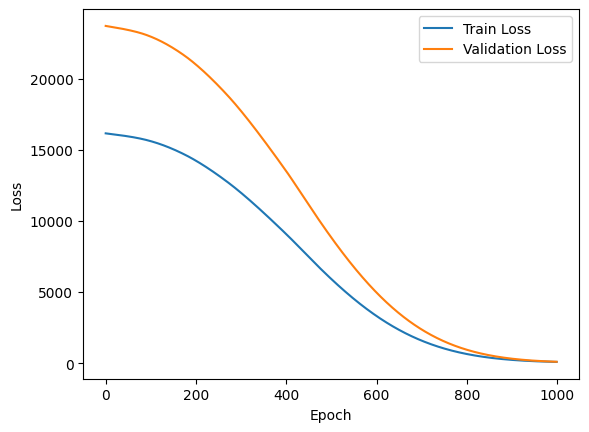

In [3]:
# load data 

import torch


df = (pd.read_csv('../Data/modeling_data.csv')
      )

target_col = 'total_fresh_weight_g'

X = df.drop(columns=[target_col]).to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)

feature_names = df.drop(columns=[target_col]).columns.tolist()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# standardize 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


#### Neural Network Model
class BasicNN(nn.Module): # inherits from Module
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__() # call initialization from module
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x
    


# hyperparameters    
input_size = X_train_tensor.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 1000

# initialize model
model = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)

# loss function
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


# train
train_losses = []
val_losses = []

for epoch in range(num_epochs):

    ### training
    model.train()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    optimizer.zero_grad() 
    loss.backward() # compute gradients
    optimizer.step() # update weights

    train_losses.append(loss.item())

    ### validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor)

    val_losses.append(val_loss.item())

    print(f"Epoch [{epoch+1}/{num_epochs}], "
            f"Train Loss: {loss.item():.4f}, "
         f"Val Loss: {val_loss.item():.4f}")
    
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
# save figure
plt.savefig('../Figures/training_validation_loss.png')
plt.show()

In [62]:
df

,total_fresh_weight_g,carbon_dioxide,temp_env,humidity,pressure,electrical_conductivity,volume,temp_nutr,volume_flow_rate,weight_lag_1,weight_lag_2
0,40.1,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,33.1,29.1
1,43.4,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,36.3,30.1
2,43.6,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,36.5,29.8
3,44.3,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,38.1,29.7
4,45.0,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,40.1,33.1
5,45.1,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,38.5,30.2
6,46.0,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,39.2,29.3
7,46.2,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,39.2,30.4
8,46.8,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,36.9,29.6
9,49.2,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,42.1,31.8


Baseline RMSE: 10.351102

Permutation results (20-repeat average):
electrical_conductivity    RMSE=27.4403  (Δ=+17.0892,  sd=2.6749)
volume_flow_rate           RMSE=27.4002  (Δ=+17.0491,  sd=3.5086)
weight_lag_1               RMSE=27.2577  (Δ=+16.9066,  sd=3.1153)
temp_nutr                  RMSE=26.3365  (Δ=+15.9854,  sd=4.1457)
weight_lag_2               RMSE=24.2349  (Δ=+13.8838,  sd=2.4228)
volume                     RMSE=23.8278  (Δ=+13.4767,  sd=3.5889)
humidity                   RMSE=23.5083  (Δ=+13.1572,  sd=3.1101)
pressure                   RMSE=20.5875  (Δ=+10.2364,  sd=3.1687)
temp_env                   RMSE=18.7953  (Δ=+8.4442,  sd=2.7443)
carbon_dioxide             RMSE=16.9412  (Δ=+6.5901,  sd=2.4942)


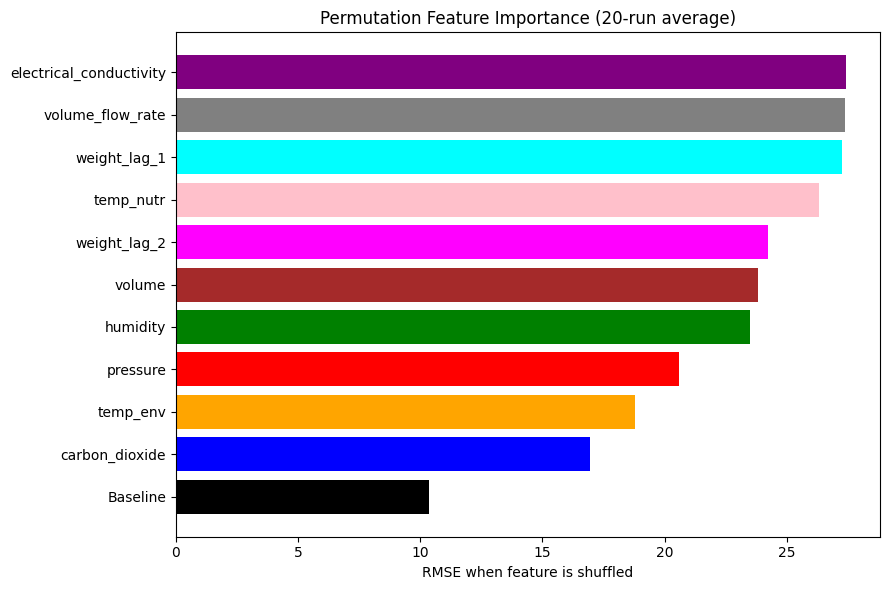

In [4]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt

# ==============================
# Set random seeds
# ==============================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# ==============================
# RMSE function
# ==============================
def rmse(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

model.eval()

# ==============================
# Baseline RMSE
# ==============================
with torch.no_grad():
    base_preds = model(X_test_tensor).cpu().numpy()

y_true = y_test_tensor.cpu().numpy()
base_rmse = rmse(base_preds, y_true)

# ==============================
# Permutation Importance (20 repeats)
# ==============================
repeats = 20
perm_results = []

X_test_base = X_test_tensor.clone()
N = X_test_base.shape[0]

for j, name in enumerate(feature_names):
    rmses = []

    for r in range(repeats):
        X_perm = X_test_base.clone()

        # shuffle feature j
        idx = torch.randperm(N)
        X_perm[:, j] = X_perm[idx, j]

        with torch.no_grad():
            preds = model(X_perm).cpu().numpy()

        rmses.append(rmse(preds, y_true))

    avg_perm_rmse = np.mean(rmses)
    std_perm_rmse = np.std(rmses)

    perm_results.append((name, avg_perm_rmse, std_perm_rmse))

# Sort by average permuted RMSE (largest first)
perm_results.sort(key=lambda x: x[1], reverse=True)

# ==============================
# Print results
# ==============================
print("Baseline RMSE:", round(base_rmse, 6))
print("\nPermutation results (20-repeat average):")

for name, avg_rmse, std_rmse in perm_results:
    delta = avg_rmse - base_rmse
    print(f"{name:25s}  RMSE={avg_rmse:.4f}  (Δ={delta:+.4f},  sd={std_rmse:.4f})")

# ==============================
# Plot
# ==============================

coef_colors = {
    'carbon_dioxide': 'blue',
    'temp_env': 'orange',
    'humidity': 'green',
    'pressure': 'red',
    'electrical_conductivity': 'purple',
    'volume': 'brown',
    'temp_nutr': 'pink',
    'volume_flow_rate': 'gray',
    'weight_lag_1': 'cyan',
    'weight_lag_2': 'magenta'
}

baseline_color = "black"

names = [n for n, _, _ in perm_results]
rmses = [r for _, r, _ in perm_results]
colors = [coef_colors.get(name, 'black') for name in names]

# Add baseline as separate bar
names_plot = names + ["Baseline"]
rmses_plot = rmses + [base_rmse]
colors_plot = colors + [baseline_color]

plt.figure(figsize=(9, 6))
plt.barh(names_plot[::-1], rmses_plot[::-1], color=colors_plot[::-1])

plt.xlabel("RMSE when feature is shuffled")
plt.title("Permutation Feature Importance (20-run average)")
plt.tight_layout()

plt.savefig('../Figures/permutation_importance.png', bbox_inches='tight')
plt.show()

shows importance for automation per var


# Sensitivity analysis 


## Changes in electrical conductivity 
* We will modify the EC values by +-10 percent and observe the changes in model's predictions. 

In [19]:
# baseline predictions

# fucntion that returns list of predictions after feature perturbation
def get_perturbed_predictions(model, X_test_tensor, feature_name, perturbation=0.1):
    with torch.no_grad():
        baseline_preds = model(X_test_tensor)

        X_perturbed = X_test_tensor.clone()
        X_perturbed[:, feature_names.index(feature_name)] *= (1 + perturbation)

        perturbed_preds = model(X_perturbed)

    return baseline_preds, perturbed_preds


get_perturbed_predictions(model, X_test_tensor, 'electrical_conductivity', perturbation=0.1)


perturbation_results = []

for feature in feature_names:

    baseline_preds, perturbed_plus_10 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=0.1
    )

    _, perturbed_minus_10 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=-0.1
    )

    _, perturbed_plus_20 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=0.2
    )

    _, perturbed_minus_20 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=-0.2
    )

    _, perturbed_plus_50 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=0.5
    )

    _, perturbed_minus_50 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=-0.5
    )

    _, perturbed_plus_80 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=0.8
    )

    _, perturbed_minus_80 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=-0.8
    )

    plus_10_effect = (perturbed_plus_10 - baseline_preds).mean().item()
    minus_10_effect = (perturbed_minus_10 - baseline_preds).mean().item()
    plus_20_effect = (perturbed_plus_20 - baseline_preds).mean().item()
    minus_20_effect = (perturbed_minus_20 - baseline_preds).mean().item()
    plus_50_effect = (perturbed_plus_50 - baseline_preds).mean().item()
    minus_50_effect = (perturbed_minus_50 - baseline_preds).mean().item()
    plus_80_effect = (perturbed_plus_80 - baseline_preds).mean().item()
    minus_80_effect = (perturbed_minus_80 - baseline_preds).mean().item()

    perturbation_results.append({
        "feature": feature,
        "+10% effect (g)": plus_10_effect,
        "-10% effect (g)": minus_10_effect,
        "+20% effect (g)": plus_20_effect,
        "-20% effect (g)": minus_20_effect,
        "+50% effect (g)": plus_50_effect,
        "-50% effect (g)": minus_50_effect,
        "+80% effect (g)": plus_80_effect,
        "-80% effect (g)": minus_80_effect
    })

perturbation_df = pd.DataFrame(perturbation_results)

perturbation_df = perturbation_df.sort_values(
    by="+10% effect (g)",
    key=lambda x: x.abs(),
    ascending=False
).reset_index(drop=True)

perturbation_df = perturbation_df.round(4)

perturbation_df


,feature,+10% effect (g),-10% effect (g),+20% effect (g),-20% effect (g),+50% effect (g),-50% effect (g),+80% effect (g),-80% effect (g)
0,electrical_conductivity,1.6130,-1.6090,3.2596,-3.2180,8.2459,-8.0454,13.2819,-12.8506
1,weight_lag_1,1.5398,-1.5368,3.0914,-3.0737,7.7882,-7.6851,12.5271,-12.2957
2,volume,1.4389,-1.4389,2.8818,-2.8779,7.2263,-7.1948,11.5719,-11.5017
3,temp_nutr,1.3222,-1.3207,2.6529,-2.6417,6.6591,-6.6048,10.6643,-10.5573
4,weight_lag_2,1.2799,-1.2800,2.5639,-2.5600,6.4585,-6.4013,10.3725,-10.2468
5,pressure,1.1519,-1.1520,2.3038,-2.3044,5.7586,-5.7443,9.2136,-9.1644
6,humidity,1.1003,-1.1003,2.2005,-2.2007,5.5008,-5.5004,8.8007,-8.7971
7,volume_flow_rate,0.9838,-0.9841,1.9676,-1.9684,4.9221,-4.9214,7.8815,-7.8744
8,temp_env,0.4902,-0.4648,0.9805,-0.9107,2.5955,-2.0982,4.6627,-3.2504
9,carbon_dioxide,0.4727,-0.4728,0.9449,-0.9429,2.3610,-2.2684,3.7770,-3.4676


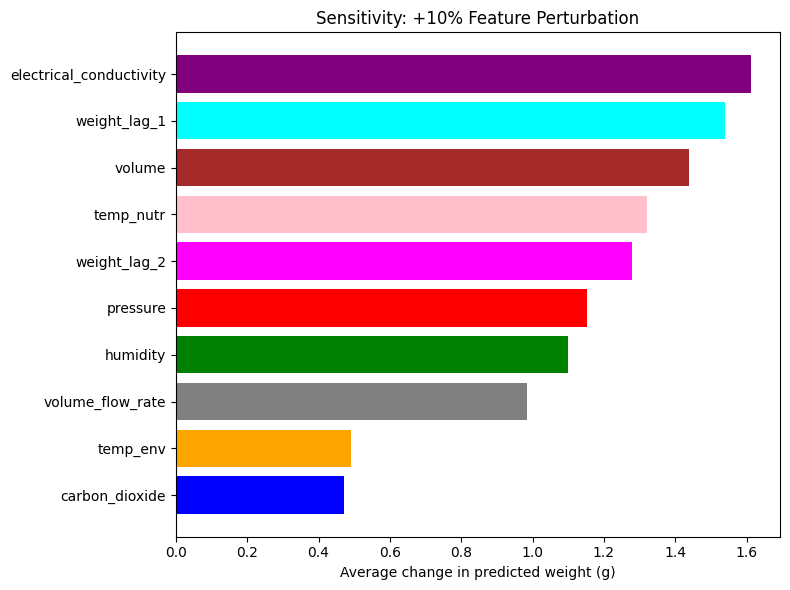

In [17]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

# map feature colors
colors = perturbation_df["feature"].map(coef_colors)

plt.figure(figsize=(8,6))

plt.barh(
    perturbation_df["feature"],
    perturbation_df["+10% effect (g)"],
    color=colors
)

plt.xlabel("Average change in predicted weight (g)")
plt.title("Sensitivity: +10% Feature Perturbation")

plt.gca().invert_yaxis()  # most important feature at top

plt.tight_layout()
plt.show()

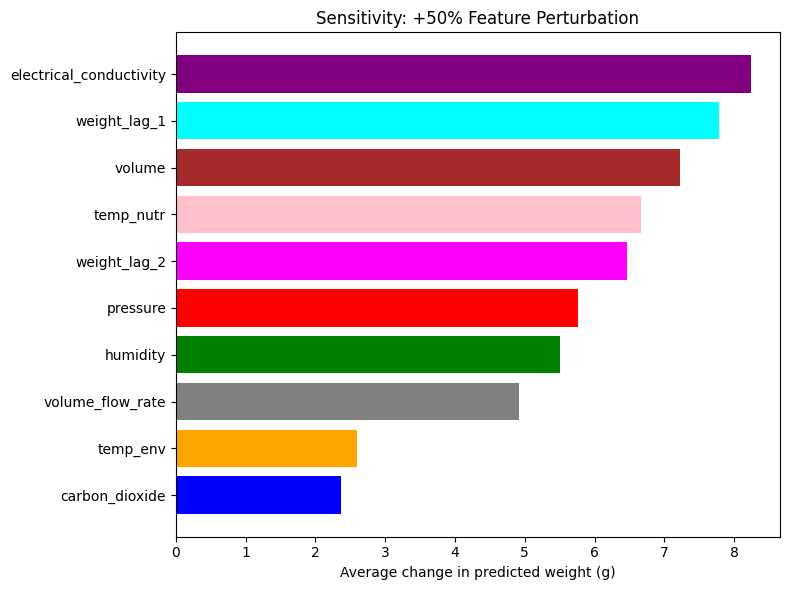

In [18]:
import matplotlib.pyplot as plt

# map feature colors
colors = perturbation_df["feature"].map(coef_colors)

plt.figure(figsize=(8,6))

plt.barh(
    perturbation_df["feature"],
    perturbation_df["+50% effect (g)"],
    color=colors
)

plt.xlabel("Average change in predicted weight (g)")
plt.title("Sensitivity: +50% Feature Perturbation")

plt.gca().invert_yaxis()  # most important feature at top

plt.tight_layout()
plt.show()

In [8]:
feature_names

['carbon_dioxide',
 'temp_env',
 'humidity',
 'pressure',
 'electrical_conductivity',
 'volume',
 'temp_nutr',
 'volume_flow_rate',
 'weight_lag_1',
 'weight_lag_2']

In [7]:
X_perturbed

tensor([[ 0.3882,  0.6848,  0.5348,  0.4080, -1.0533, -0.2341,  0.1089,  0.3190,
         -0.9883, -1.0382],
        [ 0.3882,  0.6848,  0.5348,  0.4080, -1.0533, -0.2341,  0.1089,  0.3190,
         -0.8634, -0.9943],
        [ 1.9216,  1.5362, -1.2943, -0.6382, -0.3300,  0.6714, -1.7024,  0.5275,
         -0.2039, -0.0853],
        [-0.7614, -0.8632,  0.8311,  1.4081,  1.8544, -1.2889,  0.7234,  0.3018,
          0.9530,  0.8317],
        [-0.4793, -1.5848,  0.1200, -0.1032, -0.9067,  0.4773, -0.5976,  0.3177,
         -0.7453, -0.7431],
        [ 0.1771,  0.0348,  1.4742,  1.0667,  1.0198, -1.4963,  1.6058, -2.4075,
          1.9711,  1.8683],
        [ 1.9216,  1.5362, -1.2943, -0.6382, -0.3300,  0.6714, -1.7024,  0.5275,
         -0.1808, -0.1252],
        [-0.7614, -0.8632,  0.8311,  1.4081,  1.8544, -1.2889,  0.7234,  0.3018,
          0.9067,  0.6323],
        [-0.4793, -1.5848,  0.1200, -0.1032, -0.9067,  0.4773, -0.5976,  0.3177,
         -0.7292, -0.6793],
        [ 0.1771,  

## 

# Ablation study 

REMOVING FEATURE: carbon_dioxide
Feature removed: carbon_dioxide
RMSE: 11.1713


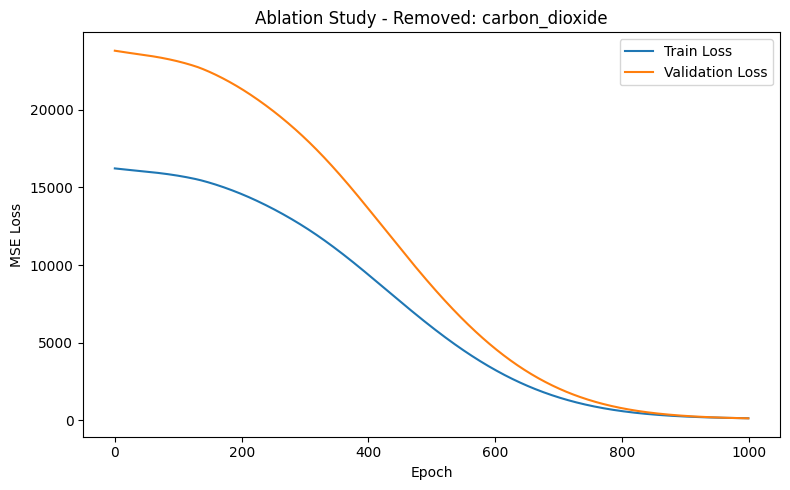

REMOVING FEATURE: temp_env
Feature removed: temp_env
RMSE: 15.1467


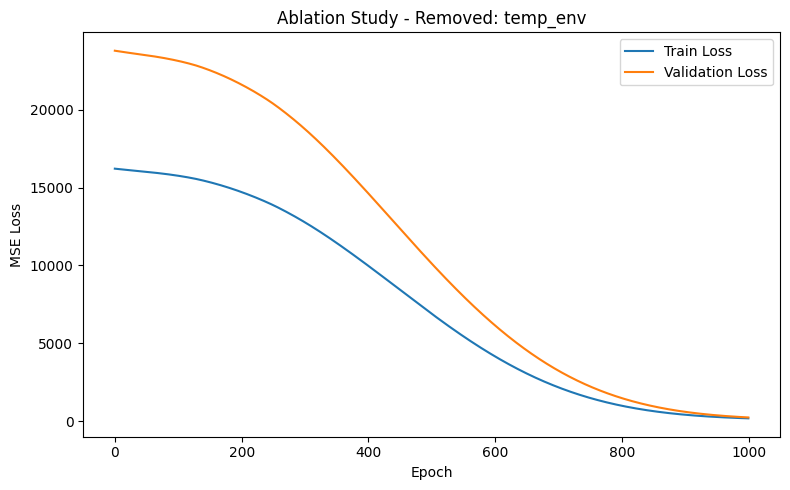

REMOVING FEATURE: humidity
Feature removed: humidity
RMSE: 12.1438


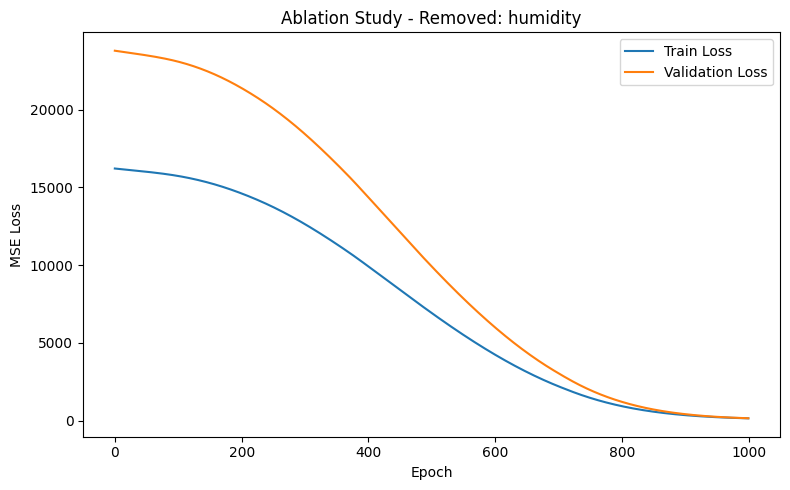

REMOVING FEATURE: pressure
Feature removed: pressure
RMSE: 14.1742


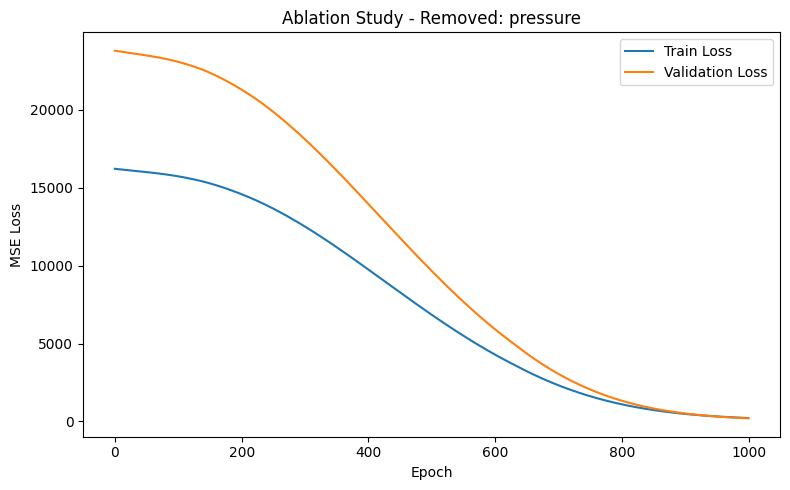

REMOVING FEATURE: electrical_conductivity
Feature removed: electrical_conductivity
RMSE: 13.3740


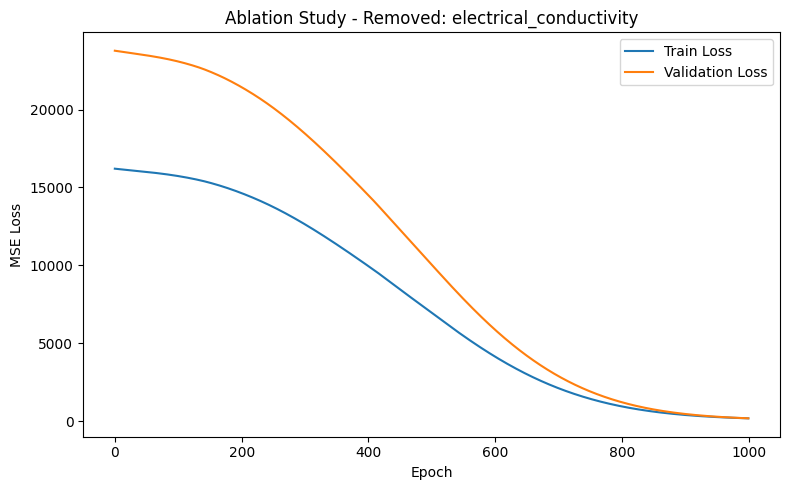

REMOVING FEATURE: volume
Feature removed: volume
RMSE: 13.5410


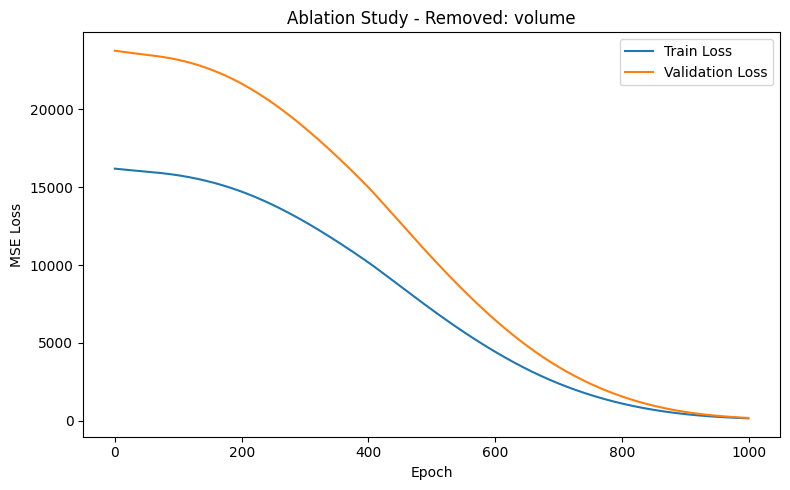

REMOVING FEATURE: temp_nutr
Feature removed: temp_nutr
RMSE: 15.5705


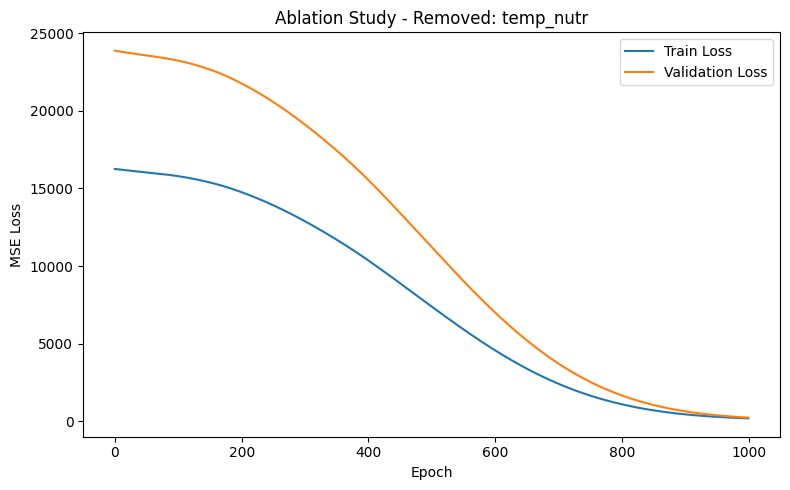

REMOVING FEATURE: volume_flow_rate
Feature removed: volume_flow_rate
RMSE: 16.2626


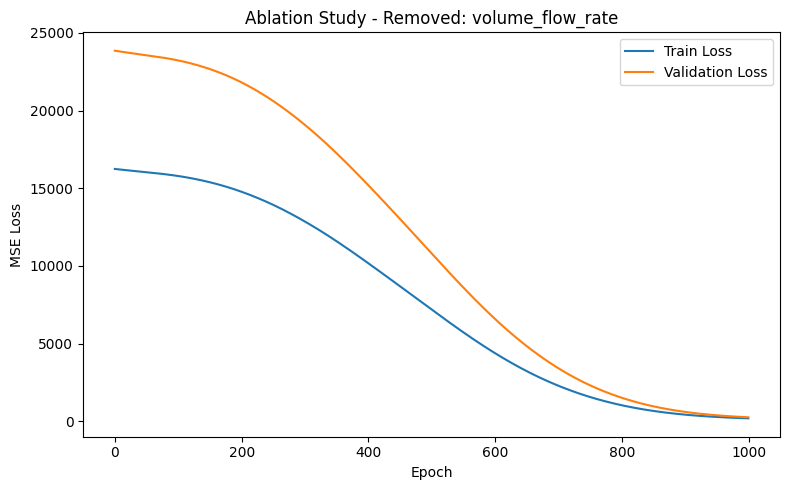

REMOVING FEATURE: weight_lag_1
Feature removed: weight_lag_1
RMSE: 13.0554


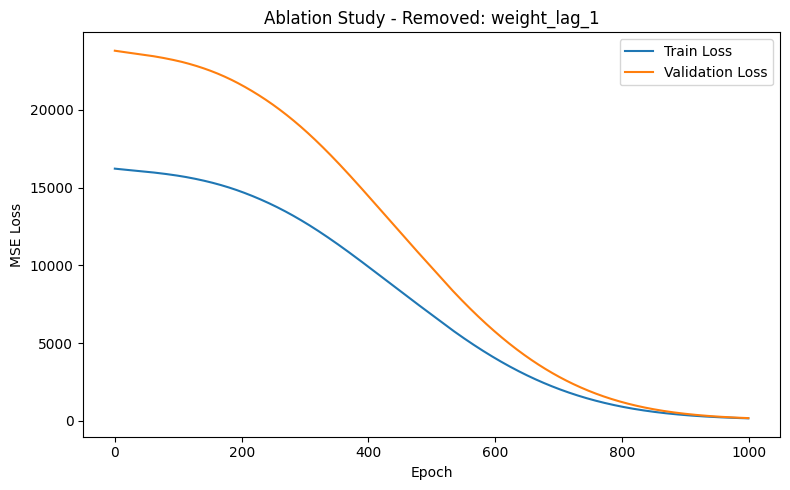

REMOVING FEATURE: weight_lag_2
Feature removed: weight_lag_2
RMSE: 14.5778


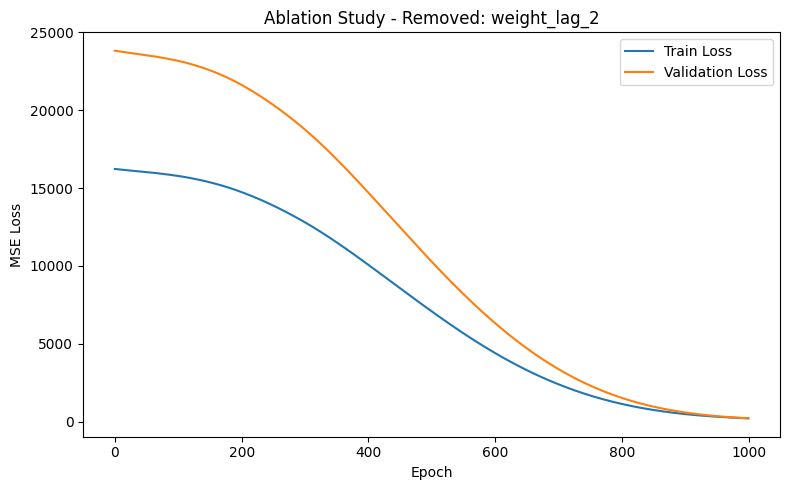


Ablation study summary:
           feature_removed       rmse
0         volume_flow_rate  16.262589
1                temp_nutr  15.570484
2                 temp_env  15.146693
3             weight_lag_2  14.577844
4                 pressure  14.174159
5                   volume  13.540987
6  electrical_conductivity  13.373953
7             weight_lag_1  13.055375
8                 humidity  12.143840
9           carbon_dioxide  11.171263


In [ ]:
# === Ablation study: remove one feature at a time, retrain, plot losses, print RMSE ===

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)


# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv('../Data/modeling_data.csv')

target_col = 'total_fresh_weight_g'
all_features = df.drop(columns=[target_col]).columns.tolist()


# -----------------------------
# Model
# -----------------------------
class BasicNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


# -----------------------------
# Same hyperparameters/settings
# -----------------------------
hidden_size = 32
output_size = 1
learning_rate = 0.001
num_epochs = 1000


# -----------------------------
# Store ablation results
# -----------------------------
ablation_results = []


# -----------------------------
# Loop through each feature removal
# -----------------------------
for feature_removed in all_features:
    print("=" * 80)
    print(f"REMOVING FEATURE: {feature_removed}")

    # 
    kept_features = [f for f in all_features if f != feature_removed]

    X = df[kept_features].to_numpy(dtype=np.float32)
    y = df[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)

    # 
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # s
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_test = scaler.transform(X_test).astype(np.float32)

    # tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

    # re-seed before each model so runs are comparable
    set_seed(42)

    # fresh model each time
    input_size = X_train_tensor.shape[1]
    model = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []

    # train
    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_test_tensor)
            val_loss = criterion(val_outputs, y_test_tensor)

        val_losses.append(val_loss.item())

    # final predictions + RMSE
    model.eval()
    with torch.no_grad():
        final_preds = model(X_test_tensor).numpy()

    rmse = np.sqrt(mean_squared_error(y_test, final_preds))

    print(f"Feature removed: {feature_removed}")
    print(f"RMSE: {rmse:.4f}")

    ablation_results.append({
        "feature_removed": feature_removed,
        "rmse": rmse
    })

    # plot losses for this ablation run
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Ablation Study - Removed: {feature_removed}")
    plt.legend()
    plt.tight_layout()

    # optional save
    safe_name = feature_removed.replace("/", "_")
    plt.savefig(f"../Figures/ablation_removed_{safe_name}.png")
    plt.show()


# -----------------------------
# Final summary dataframe
# -----------------------------
ablation_df = pd.DataFrame(ablation_results).sort_values("rmse", ascending=False).reset_index(drop=True)

print("\nAblation study summary:")
print(ablation_df)

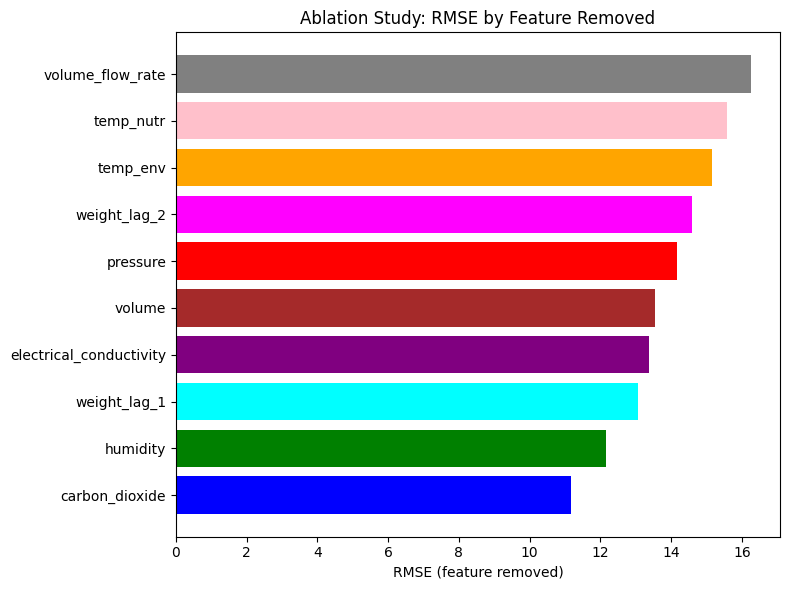

In [ ]:
# === Plot RMSE for each feature removed 

colors = ablation_df["feature_removed"].map(coef_colors)

plt.figure(figsize=(8,6))

plt.barh(
    ablation_df["feature_removed"],
    ablation_df["rmse"],
    color=colors
)

plt.xlabel("RMSE (feature removed)")
plt.title("Ablation Study: RMSE by Feature Removed")

plt.gca().invert_yaxis()  # highest RMSE at top

plt.tight_layout()
plt.savefig("../Figures/ablation_rmse_by_feature.png")
plt.show()